# Detección de objetos

La detección de objetos es un área dentro de la **visión por computador** (así como lo es la clasificación de imágenes que hemos visto detalladamente en el cuadernillo ```502```).

Esta técnica es más complicada que la anterior, dado que no solo buscamos determinar una etiqueta para una imagen, sino determinar en qué posición de dicha imagen existe un determinado objeto.

Esta técnica es la técnica por excelencia a la hora de hablar de la Inteligencia Artificial en los medios de comunicación, son los típicos casos en los que a una imagen se le añade un recuadro verde que indica que dentro de ese recuadro _existe_ un objeto.

Fíjate, por tanto, que estos _objetos_ pueden ser también seres vivos, como personas o animales. En general, no buscamos determinar _dónde se encuentra el objeto_, sino _dónde se encuentran TODOS los objetos_ que el modelo pueda determinar: es decir, en una misma imagen podemos encontrar varios recuadros (que, a partir de ahora, llamaremos **bboxes o _bounding boxes_**).

Como esta técnica es una especie de _evolución_ de la clasificación de imágenes, podemos aplicar todas las técnicas vistas en el cuadernillo ```502``` en este nuevo cuadernillo. **¡Pero cuidado!**: aplicar algunas técnicas podría no tener sentido o producir valores sin sentido. Por ejemplo, a la hora de aplicar aumento de datos, también tendremos que evaluar los cambios que sufren las **_bounding boxes_**, por ejemplo, en un giro o en una perspectiva.

## La métrica por excelencia en la detección de objetos

Fíjate en que la detección de objetos no es un problema de regresión ni de clasificación, por lo que las métricas que hemos visto hasta ahora no nos sirven: tenemos que definir otras.

En general, se suele usar la métrica [IoU](https://es.wikipedia.org/wiki/%C3%8Dndice_de_Jaccard) (_intersection over union_), que determina cómo de bueno es el rectángulo generado según la etiqueta aportada. Por cierto: no lo hemos mencionado, pero claramente las _etiquetas_ que necesitan los datos para este tipo de problemas es una lista de las coordenadas en las que se encuentran las **bboxes**. Por simplicidad, en este cuadernillo solo usaremos la ```valid_loss```.

Hay varias formas de determinar estas coordenadas, y cada forma de hacerlo da lugar a nuevas codificaciones y nomenclaturas. Las más comunes con [```PASCAL VOC```](http://host.robots.ox.ac.uk/pascal/VOC/) y [```COCO```](https://paperswithcode.com/dataset/coco), que usan formatos ```xml``` y ```json``` respectivamente.

Además, también tenemos distintas arquitecturas para entrenar modelos que realicen esta tarea, como [```YOLO```](https://es.wikipedia.org/wiki/Algoritmo_You_Only_Look_Once_(YOLO)) (versiones hasta la 8) o [```FCOS```](https://arxiv.org/abs/1904.01355), entre otras muchas.

Ten en cuenta que, dado que actualmente la **visión por computador** está en un avance constante, las estrategias que menciono aquí (aunque sean _relativamente_ nuevas) podrían quedar desfasadas. En ese sentido, no te centres en cómo se usan, sino en qué se busca encontrar conceptualmente para entrenar estos modelos.

## Un modelo de detección de objetos

Hasta ahora hemos usado la librería de FastAI para entrenar nuestros modelos. Sin embargo, esta librería funciona especialmente mal para los modelos de tipo **detección de objetos**, ya que son modelos bicéfalos (reciben una imagen y sus anotaciones), generando una imagen anotada. Por eso, **NO** seguiremos el tutorial que nos sugieren (aunque te lo dejo por completitud) [```FastAI```](https://walkwithfastai.com/Object_Detection).

Para arreglar este problema, usaremos otra librería de _Deep Learning_: [```HuggingFace```](https://huggingface.co/). La forma de trabajar es similar, aunque tiene ciertas diferencias.

Iremos poco a poco explicando todos los detalles, pero no dudes en preguntas todas las dudas que tengas. Como siempre.

## Librerías necesarias y ```token``` de acceso

Importaremos las librerías:
- ```datasets```. Para trabajar con los ```datasets``` de ```HuggingFace``` (que son ligeramente diferentes a los de ```FastAI```, aunque conceptualmente es lo mismo: lugares de donde recoger los datos.
- ```transformers```. Para trabajar con los ```transformers``` de ```HuggingFace```. A efectos prácticos: sus modelos.
- ```accelerate```. Para mejorar varios procesos computacionales.
- ```timm```. Ya vista en clasificación de imágenes.
- ```albumentations```. Ya vista en clasificación de imágenes.
- ```torchmetrics```. Para definir varias métricas.
- ```pycocotools```. Para ayudarnos con la nomenclatura de las anotaciones.

In [ ]:
!pip install -q datasets transformers accelerate timm
!pip install -q -U albumentations torchmetrics pycocotools

Nos registramos con nuestro ```token``` de ```HuggingFace``` para poder entrenar nuestro modelo más adelante.

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

Finalmente, definimos algunos parámetros globales del cuadernillo:
- ```MODEL_NAME```. El modelo con el que vamos a trabajar para hacer fine-tune. Podríamos usar cualquier otro del repositorio de ```HuggingFace```.
- ```IMAGE_SIZE```. El tamaño máximo de las imágenes con las que vamos a trabajar. Cuanto más grande sea el tamaño, más capacidad de cómputo necesitaremos.

In [ ]:
MODEL_NAME = "microsoft/conditional-detr-resnet-50"
IMAGE_SIZE = 480

## Recopilando y preprocesando los datos

En este problema, y para cambiar un poco de animales, vamos a tomar imágenes de canguros y vamos a intentar detectar en qué parte de la imagen está dicho canguro.

Para ello, vamos a descargarnos un _dataset_ de canguros.

In [ ]:
!git clone https://github.com/experiencor/kangaroo

fatal: destination path 'kangaroo' already exists and is not an empty directory.


Puedes ver, en el explorador de archivos, que ahora tienes un _dataset_ llamado ```kangaroo``` que tiene dos carpetas: ```annots``` y ```images```.

Fíjate (esto es muy importante siempre en los problemas de detección) en cuál es el formato de las etiquetas. En este caso, el formato es ```xml```, por lo que las etiquetas están en nomenclatura ```PASCAL VOC```.

Como queremos entrenar la arquitectura DETR, necesitamos que las notaciones estén en formato COCO. Para poder transformar las notaciones, podríamos crear un _script_ para modificarlo... pero existen otras herramientas que son muy útiles y es muy recomendado que las conozcas. En este caso, hablaremos de [roboflow](https://roboflow.com/).

En el aula virtual puedes ver el proceso de carga de datos que necesitaremos para este cuadernillo. Para poder pasar los datos a ```roboflow```, comprimimos y descargamos el conjunto de datos.

In [ ]:
%%capture
!zip -r kangaroo.zip kangaroo

A la izquierda, descarga el conjunto de datos y realiza todos los pasos de ```roboflow```.

Después, sube el ```zip``` generado a ```Google Colab``` y continúa.

Descomprimimos el conjunto de datos y creamos las carpetas que usaremos para el entrenamiento. Recuerda que, como en el cuadernillo ```502```, también creamos variables para guardar las rutas de estas carpetas.

In [ ]:
%%capture
!unzip 503-kangaroo.v2i.coco.zip
!mkdir dataset
!mv test dataset
!mv train dataset

## Creación del ```dataset```

Ahora tenemos que construir un nuevo ```dataset``` del tipo ```HuggingFace``` que recoja nuestros datos.

Lo primero que necesitamos es un generador que construya los objetos tal y como los espera recibir ```HuggingFace```.

La librería espera recibir un diccionario que defina la información para cada objeto.

In [ ]:
import json
import os
from PIL import Image

def gen():
    data_path = "/content/dataset/train"
    with open(os.path.join(data_path, "_annotations.coco.json"), "r") as f:
        annotations = json.load(f)

    for image in annotations["images"]:
        image_data = dict()
        image_data["image_id"] = image["id"] # un identificador único
        image_data["image"] = Image.open(os.path.join(data_path, image["file_name"])) # la imagen cargada en memoria
        image_data["width"] = image["width"] # la anchura
        image_data["height"] = image["height"] # la altura

        image_data["objects"] = dict() # las anotaciones
        related_annotations = [ann for ann in annotations["annotations"] if ann["image_id"] == image_data["image_id"]]
        image_data["objects"]["id"] = [ann["id"] for ann in related_annotations] # los identificadores de las anotaciones
        image_data["objects"]["area"] = [ann["area"] for ann in related_annotations] # el área total de las anotaciones
        image_data["objects"]["bbox"] = [ann["bbox"] for ann in related_annotations]
        image_data["objects"]["category"] = [ann["category_id"] - 1 for ann in related_annotations] # la categoría de cada anotación. Le resto 1 porque están desplazadas hacia [1, inf)

        yield image_data # los generadores no devuelven objetos, sino contextos (yield)

Ahora podemos cargar nuestros datos usando el generador que acabamos definir.

In [ ]:
from datasets import Dataset

dataset = Dataset.from_generator(gen)
print(dataset)

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['image_id', 'image', 'width', 'height', 'objects'],
    num_rows: 162
})


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Nuestro dataset es un solo conjunto con todos los datos. Vamos a crear los conjuntos de validación y testeo.

In [ ]:
dataset = dataset.train_test_split(0.2, seed = 33)
split = dataset["train"].train_test_split(0.15, seed = 33)
dataset["train"] = split["train"]
dataset["validation"] = split["test"]

dataset

DatasetDict({
    train: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 109
    })
    test: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 33
    })
    validation: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 20
    })
})

In [ ]:
dataset["train"][10] # un ejemplo de cómo se guarda la información

{'image_id': 21,
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x394>,
 'width': 600,
 'height': 394,
 'objects': {'area': [30751],
  'bbox': [[338, 92, 191, 161]],
  'category': [0],
  'id': [30]}}

Como siempre hemos dicho: mostramos un ejemplo para ver que todo se ha cargado correctamente.

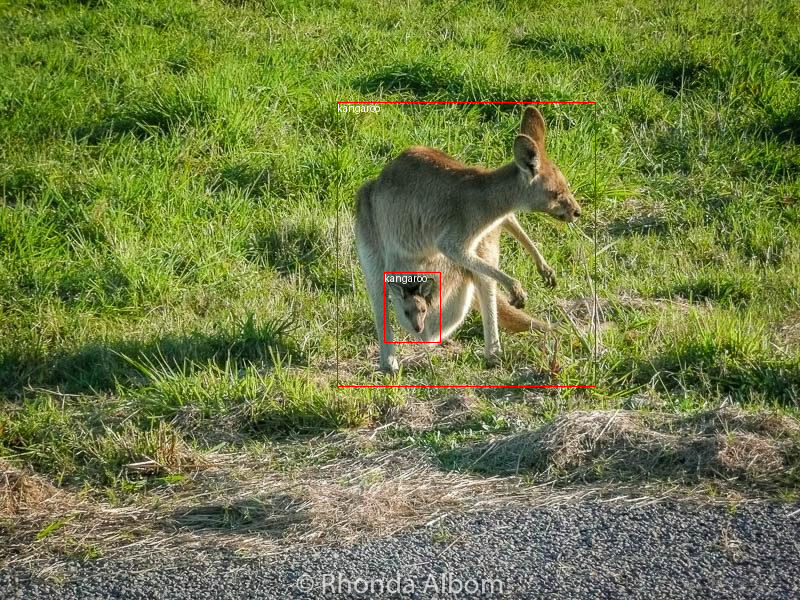

In [ ]:
import numpy as np
from PIL import ImageDraw

image = dataset["train"][30]["image"]
annotations = dataset["train"][30]["objects"]
draw = ImageDraw.Draw(image)

categories = ["kangaroo"] # nuestras posibles clases

id2label = {index: x for index, x in enumerate(categories)}
label2id = {v: k for k, v in id2label.items()}

for i in range(len(annotations["id"])):
    box = annotations["bbox"][i]
    class_idx = annotations["category"][i]
    x, y, w, h = tuple(box)

    # Check if coordinates are normalized or not
    if max(box) > 1.0:
        # Coordinates are un-normalized, no need to re-scale them
        x1, y1 = int(x), int(y)
        x2, y2 = int(x + w), int(y + h)
    else:
        # Coordinates are normalized, re-scale them
        x1 = int(x * image.width)
        y1 = int(y * image.height)
        x2 = int((x + w) * image.width)
        y2 = int((y + h) * image.height)

    draw.rectangle((x, y, x + w, y + h), outline="red", width=1)
    draw.text((x, y), id2label[class_idx], fill="white")

image

## Aumento de datos

Ahora vamos a definir cómo queremos aumentar nuestros datos en tiempo de procesamiento.

Vamos a solicitar los siguientes cambios:
- ```do_resize```. Escala los datos a las dimensiones adecuadas para el modelo.
- ```do_pad```. En el caso de que un aumento reduzca el tamaño de una imagen, añade un _padding_.

In [ ]:
from transformers import AutoImageProcessor

MAX_SIZE = IMAGE_SIZE

image_processor = AutoImageProcessor.from_pretrained(
    MODEL_NAME,
    do_resize = True,
    size = {"max_height": MAX_SIZE, "max_width": MAX_SIZE},
    do_pad = True,
    pad_size = {"height": MAX_SIZE, "width": MAX_SIZE},
)

preprocessor_config.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

The image processor of type `ConditionalDetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Finalmente, definimos los aumentos de datos tradicionales, como vimos en ```502```.

Hay un parámetro muy importante llamado ```min_visibility``` que nos permite eliminar las ```bboxes``` que, después del procesamiento, se hayan quedado demasiado pequeñas (se hayan cortado, reducido, etcétera).

In [ ]:
import albumentations as A

train_augment_and_transform = A.Compose(
    [
        A.Perspective(p=0.1, fit_output=True), # modifica la perspectiva con un 10% de probabilidad
        A.HorizontalFlip(p=0.5), # haz un giro horizontal (50%)
        A.RandomBrightnessContrast(p=0.5), # añade contraste de brillo aleatorio (50%)
        A.HueSaturationValue(p=0.1), # añade saturación (10%)
    ],
    bbox_params=A.BboxParams(format="coco", label_fields=["category"], min_visibility=0.1),
)

validation_transform = A.Compose(
    [A.NoOp()], # no hagas nada
    bbox_params=A.BboxParams(format="coco", label_fields=["category"]),
)

Ahora vamos a definir cómo se realizan estos cambios en tiempo de entrenamiento y validación. Para ello, necesitamos definir dos funciones auxiliares.

- ```format_image_annotations_as_coco```. Hace los cambios pertinentes para volver a la notación COCO (simplemente añade un paráemtro llamado ```iscrowd``` a los resultados obtenidos de la transformación).
- ```augment_and_transform_batch```. Realiza los cambios que hemos definido anteriormente (el aumento de datos). A todos los efectos prácticos, es como la clase ```TransformPipeline``` que hemos definido previamente en otros cuadernillos.

In [ ]:
def format_image_annotations_as_coco(image_id, categories, areas, bboxes):
    """Format one set of image annotations to the COCO format

    Args:
        image_id (str): image id. e.g. "0001"
        categories (List[int]): list of categories/class labels corresponding to provided bounding boxes
        areas (List[float]): list of corresponding areas to provided bounding boxes
        bboxes (List[Tuple[float]]): list of bounding boxes provided in COCO format
            ([center_x, center_y, width, height] in absolute coordinates)

    Returns:
        dict: {
            "image_id": image id,
            "annotations": list of formatted annotations
        }
    """
    annotations = []
    for category, area, bbox in zip(categories, areas, bboxes):
        formatted_annotation = {
            "image_id": image_id,
            "category_id": category,
            "iscrowd": 0,
            "area": area,
            "bbox": list(bbox),
        }
        annotations.append(formatted_annotation)

    return {
        "image_id": image_id,
        "annotations": annotations,
    }


In [ ]:
def augment_and_transform_batch(examples, transform, image_processor, return_pixel_mask=False):
    """Apply augmentations and format annotations in COCO format for object detection task"""

    images = []
    annotations = []
    for image_id, image, objects in zip(examples["image_id"], examples["image"], examples["objects"]):
        image = np.array(image.convert("RGB"))

        # Normalize bounding boxes to [0, 1]
        bboxes = objects["bbox"]
        bboxes = [[x / image.shape[1], y / image.shape[0], w / image.shape[1], h / image.shape[0]] for x, y, w, h in bboxes]

        # apply augmentations
        output = transform(image=image, bboxes=bboxes, category=objects["category"])
        images.append(output["image"])

        # Clip bounding boxes to [0, 1] after augmentation
        output["bboxes"] = [[np.clip(x, 0, 1), np.clip(y, 0, 1), np.clip(w, 0, 1), np.clip(h, 0, 1)] for x, y, w, h in output["bboxes"]]

        # format annotations in COCO format
        formatted_annotations = format_image_annotations_as_coco(
            image_id, output["category"], objects["area"], output["bboxes"]
        )
        annotations.append(formatted_annotations)

    # Apply the image processor transformations: resizing, rescaling, normalization
    result = image_processor(images=images, annotations=annotations, return_tensors="pt")

    if not return_pixel_mask:
        result.pop("pixel_mask", None)

    return result

Finalmente, apoyándonos en las funciones auxiliares, definimos las transformaciones para cada conjunto de datos de nuestro _dataset_.

In [ ]:
from functools import partial # esta función me permite definir funciones que reciban menos parámetros de lo normal, fijando algunos de ellos

train_transform_batch = partial(augment_and_transform_batch, transform=train_augment_and_transform, image_processor=image_processor)
validation_transform_batch = partial(augment_and_transform_batch, transform=validation_transform, image_processor=image_processor)

dataset["train"] = dataset["train"].with_transform(train_transform_batch)
dataset["validation"] = dataset["validation"].with_transform(validation_transform_batch)
dataset["test"] = dataset["test"].with_transform(validation_transform_batch)

Podemos ver cómo ha quedado la misma imagen que habíamos mostrado como ejemplo, ahora se ve así (ya está lista para ser utilizada).

In [ ]:
dataset["train"][30]

{'pixel_values': tensor([[[-1.1760, -1.1932, -1.1589,  ..., -0.8507, -0.9192, -0.9877],
          [-1.1075, -1.0562, -1.0733,  ..., -0.7308, -0.9877, -0.9534],
          [-0.8507, -0.8335, -1.0219,  ..., -0.6623, -0.7650, -0.7137],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-0.6001, -0.6001, -0.5651,  ..., -0.4076, -0.4951, -0.5651],
          [-0.5126, -0.4601, -0.4951,  ..., -0.2850, -0.5651, -0.5301],
          [-0.2675, -0.2500, -0.4601,  ..., -0.2150, -0.3200, -0.3025],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-1.8044, -1.8044, -1.8044,  ..., -1.6650, -1.6824, -1.6999],
          [-

## Entrenamiento (preparación)

Para realizar nuestro entrenamiento, necesitamos definir algunas funciones adicionales para trabajar con los datos. Las explicamos de forma general:

Primero, necesitamos una función que nos permita "agrupar" los datos de un _batch_. Recuerda que, en el entrenamiento, varias imágenes se envían a la vez al modelo. Estas imágenes se agrupan en la misma matriz para ser procesadas de forma paralela.

In [ ]:
import torch

def collate_fn(batch):
    data = {}
    data["pixel_values"] = torch.stack([x["pixel_values"] for x in batch])
    data["labels"] = [x["labels"] for x in batch]
    if "pixel_mask" in batch[0]:
        data["pixel_mask"] = torch.stack([x["pixel_mask"] for x in batch])

    return data

Aunque estemos trabajando con COCO, necesitamos una función que convierta los resultados a PASCAL para poder utilizar métricas que ya estén definidas. Esta función hace esa conversión.

In [ ]:
from transformers.image_transforms import center_to_corners_format

def convert_bbox_yolo_to_pascal(boxes, image_size):
    """
    Convert bounding boxes from YOLO format (x_center, y_center, width, height) in range [0, 1]
    to Pascal VOC format (x_min, y_min, x_max, y_max) in absolute coordinates.

    Args:
        boxes (torch.Tensor): Bounding boxes in YOLO format
        image_size (Tuple[int, int]): Image size in format (height, width)

    Returns:
        torch.Tensor: Bounding boxes in Pascal VOC format (x_min, y_min, x_max, y_max)
    """
    # convert center to corners format
    boxes = center_to_corners_format(boxes)

    # convert to absolute coordinates
    height, width = image_size
    boxes = boxes * torch.tensor([[width, height, width, height]])

    return boxes

## Entrenamiento (definición)

Por fin, podemos definir nuestro ```modelo```.

In [ ]:
from transformers import AutoModelForObjectDetection

model = AutoModelForObjectDetection.from_pretrained(
    MODEL_NAME, # nombre del modelo sobre el que hacer finetune
    id2label=id2label, # la función para pasar de ids a nombres
    label2id=label2id, # la función para pasar de nombres a ids
    ignore_mismatched_sizes=True, # ignoramos los tamaños incorrectos
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/174M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

Loading weights:   0%|          | 0/588 [00:00<?, ?it/s]

ConditionalDetrForObjectDetection LOAD REPORT from: microsoft/conditional-detr-resnet-50
Key                                                                         | Status     |                                                                                      
----------------------------------------------------------------------------+------------+--------------------------------------------------------------------------------------
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encode

Modelo creado, ahora necesitamos definir los parámetros del entrenamiento.

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="detr_finetuned_kangaroo", # para guardar el modelo
    num_train_epochs=5, # número de épocas de entrenamiento
    fp16=True, # si usamos una precisión de fp16
    per_device_train_batch_size=8, # tamaño del batch
    dataloader_num_workers=2, # lo he ejecutado con 4 y me ha recomendado usar solo 2
    learning_rate=5e-5, # learning rate

    # otros parámetros recomendados
    lr_scheduler_type="cosine",
    weight_decay=1e-4,
    max_grad_norm=0.01,
    greater_is_better=True,
    load_best_model_at_end=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    eval_do_concat_batches=False,

    # sobre huggingface: no lo subas a ningún lado
    push_to_hub=False,
    report_to="none"
)

## Entrenamiento (entrenamiento =)

Y, finalmente...

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    processing_class=image_processor,
    data_collator=collate_fn
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,8.899240
2,No log,2.257970
3,No log,1.840372
4,No log,1.666065
5,No log,1.644857


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=70, training_loss=7.704894147600446, metrics={'train_runtime': 85.9126, 'train_samples_per_second': 6.344, 'train_steps_per_second': 0.815, 'total_flos': 9.7909447797504e+16, 'train_loss': 7.704894147600446, 'epoch': 5.0})

Obtenemos nuestras métricas de validación.

In [ ]:
metrics = trainer.evaluate(eval_dataset=dataset["test"], metric_key_prefix="test")
metrics

{'test_loss': 8.318142890930176,
 'test_runtime': 7.2359,
 'test_samples_per_second': 4.561,
 'test_steps_per_second': 0.691,
 'epoch': 5.0}

## Inferencia

Para finalizar el ejemplo, vamos a realizar inferencia.

Este proceso es complicado debido a que nuestro conjunto de datos tiene una cantidad de datos **muy pequeña**. Aún así, lo vamos a intentar.

Cogemos una imagen aleatoria de Internet.

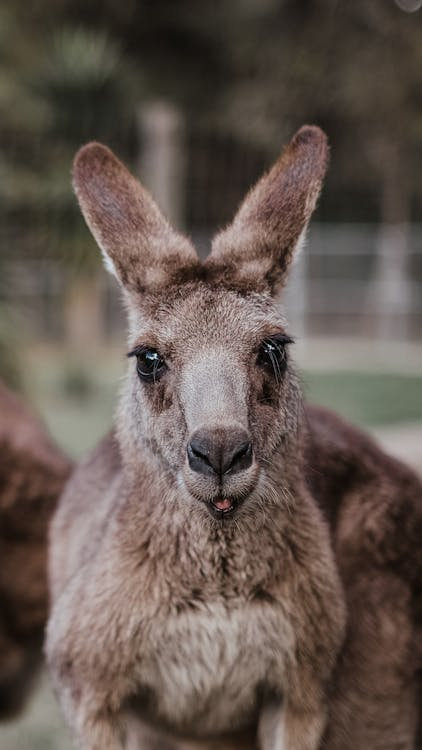

In [ ]:
import torch
import requests

from PIL import Image, ImageDraw
from transformers import AutoImageProcessor, AutoModelForObjectDetection

url = "https://images.pexels.com/photos/5403369/pexels-photo-5403369.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1"
image = Image.open(requests.get(url, stream=True).raw)
image

Activamos las capacidades de aceleración, recogemos el _backend_ actual (la GPU) y le pasamos la imagen al modelo.

In [ ]:
from accelerate.test_utils.testing import get_backend

device, _, _ = get_backend()

Aquí podemos observar los resultados del modelo.

In [ ]:
with torch.no_grad():
    inputs = image_processor(images=[image], return_tensors="pt")
    outputs = model(**inputs.to(device))
    target_sizes = torch.tensor([[image.size[1], image.size[0]]])
    results = image_processor.post_process_object_detection(outputs, threshold=0.3, target_sizes=target_sizes)[0]

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    print(
        f"Detected {model.config.id2label[label.item()]} with confidence "
        f"{round(score.item(), 3)} at location {box}"
    )

Detected kangaroo with confidence 0.415 at location [-0.37, -2.52, 3.3, 20.88]
Detected kangaroo with confidence 0.415 at location [-0.08, -2.24, 1.13, 88.3]
Detected kangaroo with confidence 0.413 at location [331.75, 730.55, 411.29, 749.68]
Detected kangaroo with confidence 0.412 at location [274.77, 727.19, 402.73, 749.38]
Detected kangaroo with confidence 0.408 at location [-0.37, 636.61, 12.57, 751.33]
Detected kangaroo with confidence 0.407 at location [84.38, 724.69, 403.56, 749.68]
Detected kangaroo with confidence 0.407 at location [66.56, 736.05, 394.18, 750.03]
Detected kangaroo with confidence 0.406 at location [398.42, 718.64, 421.68, 749.86]
Detected kangaroo with confidence 0.406 at location [0.35, -1.15, 10.68, 14.07]
Detected kangaroo with confidence 0.403 at location [208.22, 735.59, 390.99, 749.77]
Detected kangaroo with confidence 0.403 at location [102.62, 722.45, 403.46, 749.71]
Detected kangaroo with confidence 0.401 at location [17.41, 726.69, 128.06, 749.87]
De

Y también los podemos poner "sobre" la imagen.

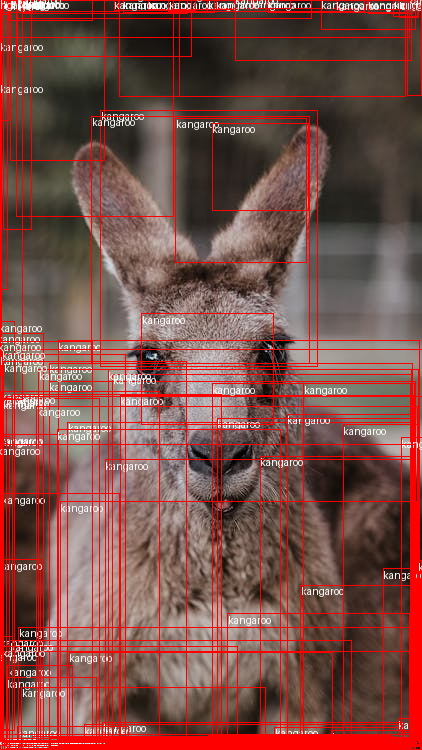

In [ ]:
draw = ImageDraw.Draw(image)

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    x, y, x2, y2 = tuple(box)
    draw.rectangle((x, y, x2, y2), outline="red", width=1)
    draw.text((x, y), model.config.id2label[label.item()], fill="white")

image

Y, como vemos, el resultado no es muy bueno.

Esto se puede deber a varias razones:
- Tenemos muy pocos datos con los que entrenar nuestro modelo.
- No estamos aplicando ningún algoritmo para evitar el sobreajuste.
- No estamos aplicando ningún algoritmo para limpiar los resultados, como ```Non-Maximum Suppression```.

# Conclusiones

Durante este cuadernillo hemos aprendido a realizar detección de objetos usando la librería de ```HuggingFace```.

Además, también hemos aprendido a utilizar ```RoboFlow```, una herramienta online y gratuita (en parte) que nos puede ayudar a realizar el proceso de etiquetado manual de imágenes o de conversión entre anotaciones.

En el siguiente cuadernillo veremos técnicas de segmentación semántica, una de las tareas más complicadas dentro de la visión por computador.